In [1]:
'''FUNDAMENTAL EXPERIMENTAL CONSTANTS'''
# These are the primary parameters that define your microscope and experiment

# Microscope Settings
ENERGY = 300e3              # Electron energy (eV) - 300 keV
CONVERGENCE_ANGLE = 100     # Semi-convergence angle (mrad)
OVERFOCUS = 1.0             # Overfocus value (nm) - positive = overfocus, 0 = in-focus

# Detector Configuration
HAADF_INNER = 110           # HAADF inner angle (mrad)
HAADF_OUTER = 250           # HAADF outer angle (mrad)
BF_MAX_ANGLE = 250          # Bright field detector max angle (mrad)
TARGET_DETECTOR_PIXELS = 64 # Target detector array size for 4D STEM

# Structure File
STRUCTURE_FILE = 'PTO6_STO6_18_18_labyrinthPoscar.vasp'
STRUCTURE_PATH = r'C:\Users\Trist\HyperSpy-bundle\MY HYPERSPY CODE'

# Scan Region
CENTER_X = 23.0             # Scan center X (Å)
CENTER_Y = 35.0             # Scan center Y (Å)
SCAN_WIDTH = 40.0           # Scan region width (Å)

# Tiling Configuration
TILE_SIZE = 4.0             # Size of each tile (Å)

print("✓ Constants loaded")
print(f"  Energy: {ENERGY/1e3:.0f} keV")
print(f"  Convergence angle: {CONVERGENCE_ANGLE} mrad")
print(f"  Overfocus: {OVERFOCUS} nm")

✓ Constants loaded
  Energy: 300 keV
  Convergence angle: 100 mrad
  Overfocus: 1.0 nm


In [2]:
'''GET MODEL AND CALCULATE ALL SIMULATION PARAMETERS'''
import ase.io
import abtem
import numpy as np
import os

# Load structure and get dimensions
full_path = os.path.join(STRUCTURE_PATH, STRUCTURE_FILE)
atoms = ase.io.read(full_path)
atoms.rotate(-90, 'y', rotate_cell=True)
atoms = abtem.orthogonalize_cell(atoms)
atoms.center(axis=2, vacuum=2.0)

cell_dims = atoms.cell.lengths()
BOX_X = cell_dims[0]
BOX_Y = cell_dims[1]
BOX_Z = cell_dims[2]
REAL_SPACE_THICKNESS = BOX_Y

# Physical constants
h = 6.626e-34
c = 3e8
e = 1.602e-19
m_e = 9.109e-31

# Relativistic wavelength
wavelength_m = h / np.sqrt(2 * m_e * ENERGY * e * (1 + ENERGY * e / (2 * m_e * c**2)))
WAVELENGTH = wavelength_m * 1e10

# Convert angles
alpha_rad = CONVERGENCE_ANGLE * 1e-3
theta_max_rad = BF_MAX_ANGLE * 1e-3
OVERFOCUS_ANGSTROM = OVERFOCUS * 10

# Diffraction-limited probe (at focus)
PROBE_FWHM_FOCUSED = 0.61 * WAVELENGTH / alpha_rad

# Geometric spreading due to overfocus
if OVERFOCUS != 0:
    geometric_spread = alpha_rad * OVERFOCUS_ANGSTROM
    PROBE_FWHM_EFFECTIVE = np.sqrt(PROBE_FWHM_FOCUSED**2 + geometric_spread**2)
else:
    PROBE_FWHM_EFFECTIVE = PROBE_FWHM_FOCUSED

# Scan step based on EFFECTIVE probe size
TARGET_OVERLAP = 0.75
SCAN_STEP = (1 - TARGET_OVERLAP) * PROBE_FWHM_EFFECTIVE

# Detector binning
native_dk_x_mrad = (1.0 / BOX_X) * WAVELENGTH * 1000
native_dk_y_mrad = (1.0 / BOX_Y) * WAVELENGTH * 1000
total_span_mrad = 2 * BF_MAX_ANGLE

best_factor = None
best_match = float('inf')
for factor in range(4, 33):
    eff_pixel_mrad = native_dk_y_mrad * factor
    array_size = int(total_span_mrad / eff_pixel_mrad)
    disk_pixels = (2 * CONVERGENCE_ANGLE) / eff_pixel_mrad
    if abs(array_size - TARGET_DETECTOR_PIXELS) < abs(best_match):
        if disk_pixels >= 8:
            best_match = array_size - TARGET_DETECTOR_PIXELS
            best_factor = factor
            best_array_size = array_size
            best_disk_pixels = disk_pixels

BF_DOWNSAMPLE = best_factor

# Depth resolution limits
DEPTH_RES_INTRINSIC = WAVELENGTH / (theta_max_rad ** 2)
eff_pixel_mrad = native_dk_y_mrad * BF_DOWNSAMPLE
eff_pixel_rad = eff_pixel_mrad * 1e-3
DEPTH_RES_SAMPLING = WAVELENGTH / (eff_pixel_rad ** 2)

# Potential sampling - Nyquist criterion (round DOWN)
POTENTIAL_SAMPLING_NYQUIST = WAVELENGTH / (2 * theta_max_rad)
POTENTIAL_SAMPLING = np.floor(POTENTIAL_SAMPLING_NYQUIST * 100) / 100

# Slice thickness - round down depth resolution
SLICE_THICKNESS = np.floor(DEPTH_RES_INTRINSIC * 100) / 100

# Ptychography reconstruction pixel size - Nyquist limit
# This is independent of scan step!
RECONSTRUCTION_PIXEL_SIZE_NYQUIST = WAVELENGTH / (2 * theta_max_rad)
RECONSTRUCTION_PIXEL_SIZE = np.floor(RECONSTRUCTION_PIXEL_SIZE_NYQUIST * 100) / 100

# Ptychography parameters
NUM_SLICES = int(np.round(REAL_SPACE_THICKNESS / DEPTH_RES_INTRINSIC))
PTYCHO_SLICE_THICKNESS = REAL_SPACE_THICKNESS / NUM_SLICES

# Reciprocal step
RECIPROCAL_STEP = BF_DOWNSAMPLE / REAL_SPACE_THICKNESS

# Summary
print("=" * 70)
print("CALCULATED PARAMETERS")
print("=" * 70)
print(f"\nStructure: {BOX_X:.2f} × {BOX_Y:.2f} × {BOX_Z:.2f} Å")
print(f"\nProbe:")
print(f"  λ = {WAVELENGTH:.4f} Å")
print(f"  FWHM (diffraction limit) = {PROBE_FWHM_FOCUSED:.3f} Å")
if OVERFOCUS != 0:
    print(f"  Overfocus = {OVERFOCUS_ANGSTROM:.2f} Å")
    print(f"  Geometric spread = {alpha_rad * OVERFOCUS_ANGSTROM:.3f} Å")
    print(f"  FWHM (effective at specimen) = {PROBE_FWHM_EFFECTIVE:.3f} Å")
print(f"\nScanning:")
print(f"  Step = {SCAN_STEP:.3f} Å ({TARGET_OVERLAP*100:.0f}% overlap)")
if OVERFOCUS != 0:
    print(f"  (Probe position spacing, not reconstruction pixel size)")
print(f"\nDetector:")
print(f"  Binning = {BF_DOWNSAMPLE}x")
print(f"  Array = {best_array_size}×{best_array_size} px")
print(f"  BF disk = {best_disk_pixels:.1f} px")
print(f"\nMultislice (Simulation):")
print(f"  Potential sampling = {POTENTIAL_SAMPLING:.2f} Å")
print(f"    (Nyquist ≤ {POTENTIAL_SAMPLING_NYQUIST:.3f} Å)")
print(f"  Slice thickness = {SLICE_THICKNESS:.2f} Å")
print(f"\nPtychography (Reconstruction):")
print(f"  Reconstruction pixel size = {RECONSTRUCTION_PIXEL_SIZE:.2f} Å")
print(f"    (Nyquist from detector: λ/2θ_max = {RECONSTRUCTION_PIXEL_SIZE_NYQUIST:.3f} Å)")
print(f"  Depth resolution = {DEPTH_RES_INTRINSIC:.2f} Å")
print(f"  Slices = {NUM_SLICES}")
print(f"  Slice thickness = {PTYCHO_SLICE_THICKNESS:.2f} Å")
print(f"  Reciprocal step = {RECIPROCAL_STEP:.4f} Å⁻¹")
if OVERFOCUS != 0:
    print(f"\nResolution Effects:")
    print(f"  HAADF/iCOM: {PROBE_FWHM_EFFECTIVE/PROBE_FWHM_FOCUSED:.2f}x worse")
    print(f"  Ptychography: Unchanged")
print(f"\nEwald Sphere Check:")
print(f"  Sampling limit = {DEPTH_RES_SAMPLING:.1f} Å")
if REAL_SPACE_THICKNESS < DEPTH_RES_SAMPLING:
    print(f"  ✓ Sample ({REAL_SPACE_THICKNESS:.1f} Å) within flat regime")
else:
    print(f"  ⚠ Sample ({REAL_SPACE_THICKNESS:.1f} Å) exceeds flat regime")
print("=" * 70)

CALCULATED PARAMETERS

Structure: 47.88 × 70.01 × 73.93 Å

Probe:
  λ = 0.0197 Å
  FWHM (diffraction limit) = 0.120 Å
  Overfocus = 10.00 Å
  Geometric spread = 1.000 Å
  FWHM (effective at specimen) = 1.007 Å

Scanning:
  Step = 0.252 Å (75% overlap)
  (Probe position spacing, not reconstruction pixel size)

Detector:
  Binning = 27x
  Array = 65×65 px
  BF disk = 26.3 px

Multislice (Simulation):
  Potential sampling = 0.03 Å
    (Nyquist ≤ 0.039 Å)
  Slice thickness = 0.31 Å

Ptychography (Reconstruction):
  Reconstruction pixel size = 0.03 Å
    (Nyquist from detector: λ/2θ_max = 0.039 Å)
  Depth resolution = 0.32 Å
  Slices = 222
  Slice thickness = 0.32 Å
  Reciprocal step = 0.3857 Å⁻¹

Resolution Effects:
  HAADF/iCOM: 8.38x worse
  Ptychography: Unchanged

Ewald Sphere Check:
  Sampling limit = 341.4 Å
  ✓ Sample (70.0 Å) within flat regime


In [3]:
'''4D STEM SIMULATION - MULTI-TILE WITH STREAMING'''
import os
import sys
import abtem
import numpy as np
import ase.io 
import dask
import dask.array as da
import zarr
import time
from dask.diagnostics import ProgressBar

# ==========================================
# WHICH TILES TO RUN
# ==========================================
TILES_TO_RUN = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]  # List of (i, j) tile coordinates
# ==========================================

# GPU SETUP
cuda_root = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1"
bin_path = os.path.join(cuda_root, 'bin')
bin_x64_path = os.path.join(bin_path, 'x64') 
os.environ["PATH"] = bin_path + os.pathsep + bin_x64_path + os.pathsep + os.environ["PATH"]
try:
    os.add_dll_directory(bin_path)
    os.add_dll_directory(bin_x64_path)
except AttributeError:
    pass 

def run_single_tile(TILE_I, TILE_J):
    TILE_NAME = f"tile{TILE_I}{TILE_J}"
    HAADF_OUTPUT = f"{TILE_NAME}_haadf.zarr"
    BF_OUTPUT = f"{TILE_NAME}_bf.zarr"
    
    print(f"{'='*60}")
    print(f"4D STEM - TILE [{TILE_I}, {TILE_J}] (STREAMING)")
    print(f"{'='*60}\n")

    # 1. Structure
    full_path = os.path.join(STRUCTURE_PATH, STRUCTURE_FILE)
    if not os.path.exists(full_path):
        print("Error: Structure file not found.")
        return
    
    atoms = ase.io.read(full_path)
    atoms.rotate(-90, 'y', rotate_cell=True)
    atoms = abtem.orthogonalize_cell(atoms)
    atoms.center(axis=2, vacuum=2.0)

    # 2. Potential
    print(f"Calculating potential (slice={SLICE_THICKNESS} Å)...")
    potential = abtem.Potential(
        atoms, 
        sampling=POTENTIAL_SAMPLING,
        slice_thickness=SLICE_THICKNESS, 
        device='cpu',
        parametrization='kirkland'
    ).build().compute()
    print(f"✓ Potential ready ({potential.array.nbytes/1e9:.2f} GB on CPU)")

    # 3. Probe
    probe = abtem.Probe(energy=ENERGY, semiangle_cutoff=CONVERGENCE_ANGLE, device='gpu')
    
    probe.aberrations.defocus = -OVERFOCUS_ANGSTROM
    print(f"Applied overfocus: {OVERFOCUS_ANGSTROM:.2f} Å")
    
    probe.grid.match(potential)

    # 4. Calculate THIS tile's boundaries
    scan_start_x = CENTER_X - SCAN_WIDTH/2
    scan_start_y = CENTER_Y - SCAN_WIDTH/2
    scan_end_x = CENTER_X + SCAN_WIDTH/2
    scan_end_y = CENTER_Y + SCAN_WIDTH/2
    
    tile_x_edges = np.arange(scan_start_x, scan_end_x, TILE_SIZE)
    tile_y_edges = np.arange(scan_start_y, scan_end_y, TILE_SIZE)
    if tile_x_edges[-1] < scan_end_x:
        tile_x_edges = np.append(tile_x_edges, scan_end_x)
    if tile_y_edges[-1] < scan_end_y:
        tile_y_edges = np.append(tile_y_edges, scan_end_y)
    
    tx_start = tile_x_edges[TILE_I]
    tx_end = tile_x_edges[TILE_I + 1]
    ty_start = tile_y_edges[TILE_J]
    ty_end = tile_y_edges[TILE_J + 1]
    
    print(f"Tile boundaries: ({tx_start:.1f}, {ty_start:.1f}) → ({tx_end:.1f}, {ty_end:.1f}) Å")
    
    # 5. Scan for THIS tile only
    tile_scan = abtem.GridScan(
        start=(tx_start, ty_start),
        end=(tx_end, ty_end),
        sampling=SCAN_STEP
    )
    
    print(f"Scan: {tile_scan.shape[0]} × {tile_scan.shape[1]} = {len(tile_scan):,} positions")

    # 6. Detectors
    det_haadf = abtem.AnnularDetector(inner=HAADF_INNER, outer=HAADF_OUTER)
    det_bf = abtem.PixelatedDetector(max_angle=BF_MAX_ANGLE)

    # 7. Build measurement graph
    print(f"\nBuilding scan graph for this tile...")
    
    measurements = probe.scan(
        potential, 
        scan=tile_scan, 
        detectors=[det_haadf, det_bf]
    )
    
    print("✓ Graph built")

    # 8. Setup outputs (LAZY - not loaded into RAM)
    haadf_dask = measurements[0].array
    bf_dask = measurements[1].array
    
    # Bin BF (LAZY)
    coarsen_dict = {2: BF_DOWNSAMPLE, 3: BF_DOWNSAMPLE}
    bf_binned = da.coarsen(np.sum, bf_dask, coarsen_dict, trim_excess=True)

    # 9. Create zarr targets
    print(f"\nCreating output files...")
    haadf_target = zarr.open(HAADF_OUTPUT, mode='w', shape=haadf_dask.shape, 
                            chunks=haadf_dask.chunksize, dtype=haadf_dask.dtype)
    bf_target = zarr.open(BF_OUTPUT, mode='w', shape=bf_binned.shape,
                        chunks=bf_binned.chunksize, dtype=bf_binned.dtype)
    
    print(f"HAADF: {haadf_dask.shape}")
    print(f"BF: {bf_binned.shape}")

    # 10. STREAM TO DISK
    print(f"\n{'='*60}")
    print(f"COMPUTING AND STREAMING TILE [{TILE_I}, {TILE_J}]")
    print("This will take 8-10 hours...")
    print("Data streams directly to disk - minimal RAM usage!")
    print(f"{'='*60}\n")
    
    start_time = time.time()
    
    with ProgressBar():
        da.store([haadf_dask, bf_binned], [haadf_target, bf_target], compute=True)
    
    compute_time = time.time() - start_time
    positions_per_sec = len(tile_scan) / compute_time

    print(f"\n{'='*60}")
    print(f"✓ TILE [{TILE_I}, {TILE_J}] COMPLETE!")
    print(f"  Time: {compute_time/60:.1f} min ({compute_time/3600:.2f} hours)")
    print(f"  Speed: {positions_per_sec:.1f} pos/sec")
    print(f"  HAADF: {HAADF_OUTPUT}")
    print(f"  BF: {BF_OUTPUT}")
    print(f"{'='*60}")

# MAIN LOOP
if __name__ == "__main__":
    print("=" * 70)
    print(f"RUNNING {len(TILES_TO_RUN)} TILES")
    print("=" * 70)
    
    total_start = time.time()
    
    for idx, (i, j) in enumerate(TILES_TO_RUN):
        print(f"\n\n*** TILE {idx+1}/{len(TILES_TO_RUN)}: [{i}, {j}] ***\n")
        run_single_tile(i, j)
    
    total_time = time.time() - total_start
    
    print("\n" + "=" * 70)
    print("ALL TILES COMPLETE!")
    print(f"Total time: {total_time/3600:.2f} hours")
    print("=" * 70)

RUNNING 9 TILES


*** TILE 1/9: [0, 0] ***

4D STEM - TILE [0, 0] (STREAMING)

Calculating potential (slice=0.31 Å)...
[########################################] | 100% Completed | 45.33 s
✓ Potential ready (3.56 GB on CPU)
Applied overfocus: 10.00 Å
Tile boundaries: (3.0, 15.0) → (7.0, 19.0) Å
Scan: 16 × 16 = 256 positions

Building scan graph for this tile...
✓ Graph built

Creating output files...
HAADF: (16, 16)
BF: (16, 16, 45, 65)

COMPUTING AND STREAMING TILE [0, 0]
This will take 8-10 hours...
Data streams directly to disk - minimal RAM usage!

[########################################] | 100% Completed | 43m 27s

✓ TILE [0, 0] COMPLETE!
  Time: 43.5 min (0.72 hours)
  Speed: 0.1 pos/sec
  HAADF: tile00_haadf.zarr
  BF: tile00_bf.zarr


*** TILE 2/9: [0, 1] ***

4D STEM - TILE [0, 1] (STREAMING)

Calculating potential (slice=0.31 Å)...
[########################################] | 100% Completed | 45.13 s
✓ Potential ready (3.56 GB on CPU)
Applied overfocus: 10.00 Å
Tile boundar

PTYCHOGRAPHY RECONSTRUCTION - TILED DATA
   Loading and stitching 9 tiles...
   Found 9/9 tiles
   Tile scan shape: (16, 16), Detector shape: (45, 65)
   Stitching to: (48, 48, 45, 65)
   Loading tile [0,0]: tile00_bf.zarr
   Loading tile [0,1]: tile01_bf.zarr
   Loading tile [0,2]: tile02_bf.zarr
   Loading tile [1,0]: tile10_bf.zarr
   Loading tile [1,1]: tile11_bf.zarr
   Loading tile [1,2]: tile12_bf.zarr
   Loading tile [2,0]: tile20_bf.zarr
   Loading tile [2,1]: tile21_bf.zarr
   Loading tile [2,2]: tile22_bf.zarr

✓ Stitched data shape: (48, 48, 45, 65)
   Memory: 0.03 GB

Depth sectioning:
   Number of slices: 98 (half of max 222)
   Slice thickness: 0.71 Å
   Probe C10 (defocus): 10.00 Å

Calibration:
   Real space step: 0.2518 Å/pixel
   Reciprocal space step: 0.3857 Å⁻¹/pixel
   Detector center: (32, 22)


Best fit rotation = -1 degrees.



INITIALIZING MULTISLICE PTYCHOGRAPHY SOLVER

Preprocessing...


Normalizing amplitudes: 100%|██████████| 2304/2304 [00:00<00:00, 3410.21probe position/s]
Performing 256 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.025, in batches of max 512 measurements.



RUNNING RECONSTRUCTION (64 ITERATIONS)


Reconstructing object and probe: 100%|██████████| 256/256 [11:24<00:00,  2.67s/ iter]



✓ Reconstruction complete in 11.41 minutes

SAVING RESULTS
✓ Data saved to 'ptycho_3d_reconstruction.npz'
  Shape: (98, 264, 356)
  Pixel size: 0.0576 Å

DONE - Run visualization cell next


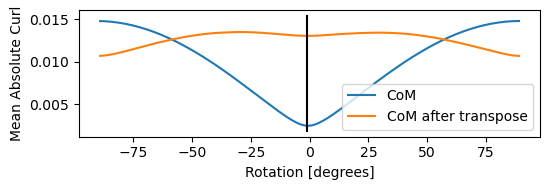

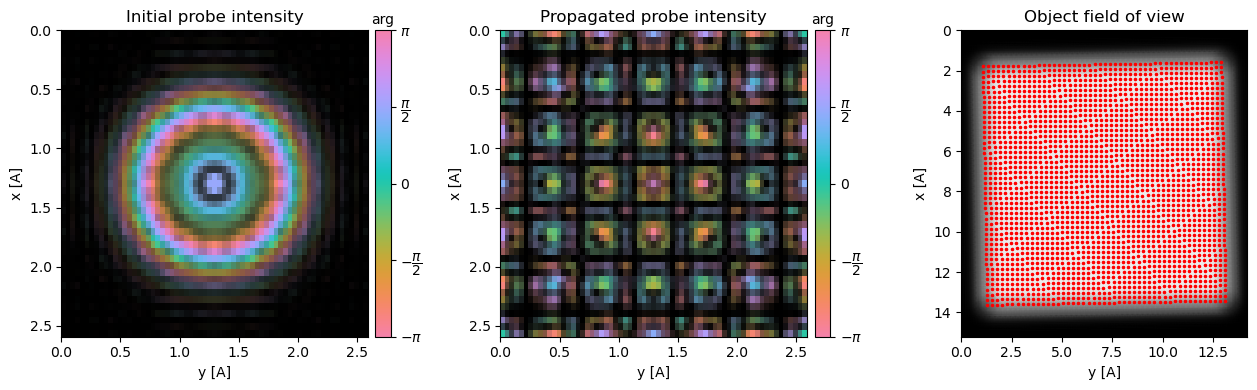

In [ ]:
'''Ptychography Reconstruction - TILED DATA VERSION'''
import py4DSTEM
import numpy as np
import zarr
import matplotlib.pyplot as plt
import os
import gc
import time
# GPU SETUP
cuda_root = r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.1"
bin_path = os.path.join(cuda_root, 'bin')
bin_x64_path = os.path.join(bin_path, 'x64') 
os.environ["PATH"] = bin_path + os.pathsep + bin_x64_path + os.pathsep + os.environ["PATH"]
try:
    os.add_dll_directory(bin_path)
    os.add_dll_directory(bin_x64_path)
except AttributeError:
    pass 
# ==========================================
# WHICH TILES TO USE FOR RECONSTRUCTION
# ==========================================
TILES_TO_USE = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]
# ==========================================

# Calculate tile grid
max_i = max(i for i, j in TILES_TO_USE)
max_j = max(j for i, j in TILES_TO_USE)
TILE_ROWS = max_i + 1
TILE_COLS = max_j + 1
BF_TILE_FILES = [f"tile{i}{j}_bf.zarr" for i, j in TILES_TO_USE]

# ==========================================
# PARAMETERS FROM PARAMS CELL
# ==========================================
ENERGY_EV = ENERGY
SEMIANGLE_MRAD = CONVERGENCE_ANGLE
SCAN_STEP_A = SCAN_STEP

# Use half max slices - more signal per slice, better convergence
RECON_NUM_SLICES = int(NUM_SLICES / 2.25)
RECON_SLICE_THICKNESS = REAL_SPACE_THICKNESS / RECON_NUM_SLICES

# Seed probe with known defocus if overfocused
polar_params = {'C10': OVERFOCUS_ANGSTROM} if OVERFOCUS != 0 else {}

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def load_and_stitch_tiles(tile_files, tile_rows, tile_cols):
    """Load tiled zarr files and stitch them into a single 4D array"""
    print(f"   Loading and stitching {len(tile_files)} tiles...")
    
    existing_files = [f for f in tile_files if os.path.exists(f)]
    if len(existing_files) == 0:
        raise FileNotFoundError(f"No tile files found! Expected files like: {tile_files[0]}")
    
    print(f"   Found {len(existing_files)}/{len(tile_files)} tiles")
    
    first_tile = zarr.open(existing_files[0], mode='r')
    tile_shape = first_tile.shape  # (scan_y, scan_x, det_y, det_x)
    det_shape = tile_shape[2:]
    
    print(f"   Tile scan shape: {tile_shape[:2]}, Detector shape: {det_shape}")
    
    tile_map = {}
    for filepath in existing_files:
        basename = os.path.basename(filepath)
        if 'tile' in basename:
            try:
                start_idx = basename.index('tile') + 4
                end_idx = start_idx
                while end_idx < len(basename) and basename[end_idx].isdigit():
                    end_idx += 1
                indices = basename[start_idx:end_idx]
                if len(indices) >= 2:
                    i = int(indices[0])
                    j = int(indices[1])
                    tile_map[(i, j)] = filepath
            except (ValueError, IndexError):
                print(f"   Warning: Could not parse indices from {filepath}")
                continue
    
    total_scan_y = tile_rows * tile_shape[0]
    total_scan_x = tile_cols * tile_shape[1]
    
    print(f"   Stitching to: ({total_scan_y}, {total_scan_x}, {det_shape[0]}, {det_shape[1]})")
    
    full_data = np.zeros((total_scan_y, total_scan_x, det_shape[0], det_shape[1]),
                         dtype=first_tile.dtype)
    
    for i in range(tile_rows):
        for j in range(tile_cols):
            if (i, j) in tile_map:
                tile_path = tile_map[(i, j)]
                print(f"   Loading tile [{i},{j}]: {os.path.basename(tile_path)}")
                tile_data = np.array(zarr.open(tile_path, mode='r'))
                y_start = i * tile_shape[0]
                y_end = y_start + tile_data.shape[0]
                x_start = j * tile_shape[1]
                x_end = x_start + tile_data.shape[1]
                full_data[y_start:y_end, x_start:x_end, :, :] = tile_data
            else:
                print(f"   Warning: Tile [{i},{j}] missing, leaving zeros")
    
    return full_data

# ==========================================
# MAIN RECONSTRUCTION FUNCTION
# ==========================================

def run_and_save():
    print("=" * 60)
    print("PTYCHOGRAPHY RECONSTRUCTION - TILED DATA")
    print("=" * 60)
    
    data_4d = load_and_stitch_tiles(BF_TILE_FILES, TILE_ROWS, TILE_COLS)
    print(f"\n✓ Stitched data shape: {data_4d.shape}")
    print(f"   Memory: {data_4d.nbytes / 1e9:.2f} GB")

    print(f"\nDepth sectioning:")
    print(f"   Number of slices: {RECON_NUM_SLICES} (half of max {NUM_SLICES})")
    print(f"   Slice thickness: {RECON_SLICE_THICKNESS:.2f} Å")
    if polar_params:
        print(f"   Probe C10 (defocus): {OVERFOCUS_ANGSTROM:.2f} Å")

    thickness_list = [RECON_SLICE_THICKNESS] * (RECON_NUM_SLICES - 1)

    # DATACUBE SETUP
    datacube = py4DSTEM.DataCube(data=data_4d)

    # CALIBRATION
    datacube.calibration.set_R_pixel_size(SCAN_STEP_A)
    datacube.calibration.set_Q_pixel_size(RECIPROCAL_STEP)
    datacube.calibration.set_R_pixel_units('A')
    datacube.calibration.set_Q_pixel_units('A^-1')

    det_y, det_x = data_4d.shape[2:]
    datacube.calibration.set_origin((det_x // 2, det_y // 2))

    print(f"\nCalibration:")
    print(f"   Real space step: {SCAN_STEP_A:.4f} Å/pixel")
    print(f"   Reciprocal space step: {RECIPROCAL_STEP:.4f} Å⁻¹/pixel")
    print(f"   Detector center: ({det_x // 2}, {det_y // 2})")

    # MEMORY CLEAN
    del data_4d
    gc.collect()

    # INITIALIZE ENGINE
    print("\n" + "=" * 60)
    print("INITIALIZING MULTISLICE PTYCHOGRAPHY SOLVER")
    print("=" * 60)

    ptycho = py4DSTEM.process.phase.MultislicePtychography(
        datacube=datacube,
        energy=ENERGY_EV,
        semiangle_cutoff=SEMIANGLE_MRAD,
        num_slices=RECON_NUM_SLICES,
        slice_thicknesses=thickness_list,
        polar_parameters=polar_params,
        device='gpu',
        verbose=True,
        object_type='complex'
    )

    print("\nPreprocessing...")
    ptycho.preprocess(
        plot_center_of_mass=False,
        crop_patterns=False,
        store_initial_arrays=True
    )

    # RECONSTRUCT
    print("\n" + "=" * 60)
    print("RUNNING RECONSTRUCTION (64 ITERATIONS)")
    print("=" * 60)

    start_time = time.time()
    ptycho.reconstruct(
        num_iter=256,
        max_batch_size=512,
        step_size=0.025,
        store_iterations=False,
        gaussian_filter=True,
        gaussian_filter_sigma=0.1,
        object_positivity=False,#false for phase objects,true for amplitude objects
        fix_potential_baseline=True,
        kz_regularization_filter=False,
        fit_probe_aberrations=True,
        fit_probe_aberrations_remove_initial=True,

        constrain_probe_amplitude=True,
        #tv_denoise=True,                 # <--- NEW: "Smart" denoising
        #tv_denoise_weights=[1e-4, 1e-4], # Start gentle. [Z-weight, XY-weight]
    )

    elapsed = time.time() - start_time
    print(f"\n✓ Reconstruction complete in {elapsed/60:.2f} minutes")

    return ptycho

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    ptycho = run_and_save()

    # SAVE DATA
    print("\n" + "=" * 60)
    print("SAVING RESULTS")
    print("=" * 60)

    recon_pixel_size = ptycho.sampling[0]

    output_file = "ptycho_3d_reconstruction.npz"
    np.savez_compressed(
        output_file,
        object_complex=ptycho.object,
        object_phase=np.angle(ptycho.object),
        probe=ptycho.probe,
        num_slices=RECON_NUM_SLICES,
        slice_thickness=RECON_SLICE_THICKNESS,
        real_space_thickness=REAL_SPACE_THICKNESS,
        scan_step_input=SCAN_STEP_A,
        reconstruction_pixel_size=recon_pixel_size,
        binning_factor=BF_DOWNSAMPLE,
        reciprocal_step=RECIPROCAL_STEP,
        overfocus_angstrom=OVERFOCUS_ANGSTROM
    )

    print(f"✓ Data saved to '{output_file}'")
    print(f"  Shape: {ptycho.object.shape}")
    print(f"  Pixel size: {recon_pixel_size:.4f} Å")

    print("\n" + "=" * 60)
    print("DONE - Run visualization cell next")
    print("=" * 60)

Loading reconstruction...
✓ Loaded: (98, 264, 356)
  Pixel size: 0.0576 Å
  Depth: 70.01 Å
  FOV: 20.51 × 15.21 Å²

✓ Saved to 'ptycho_3d_final.png'


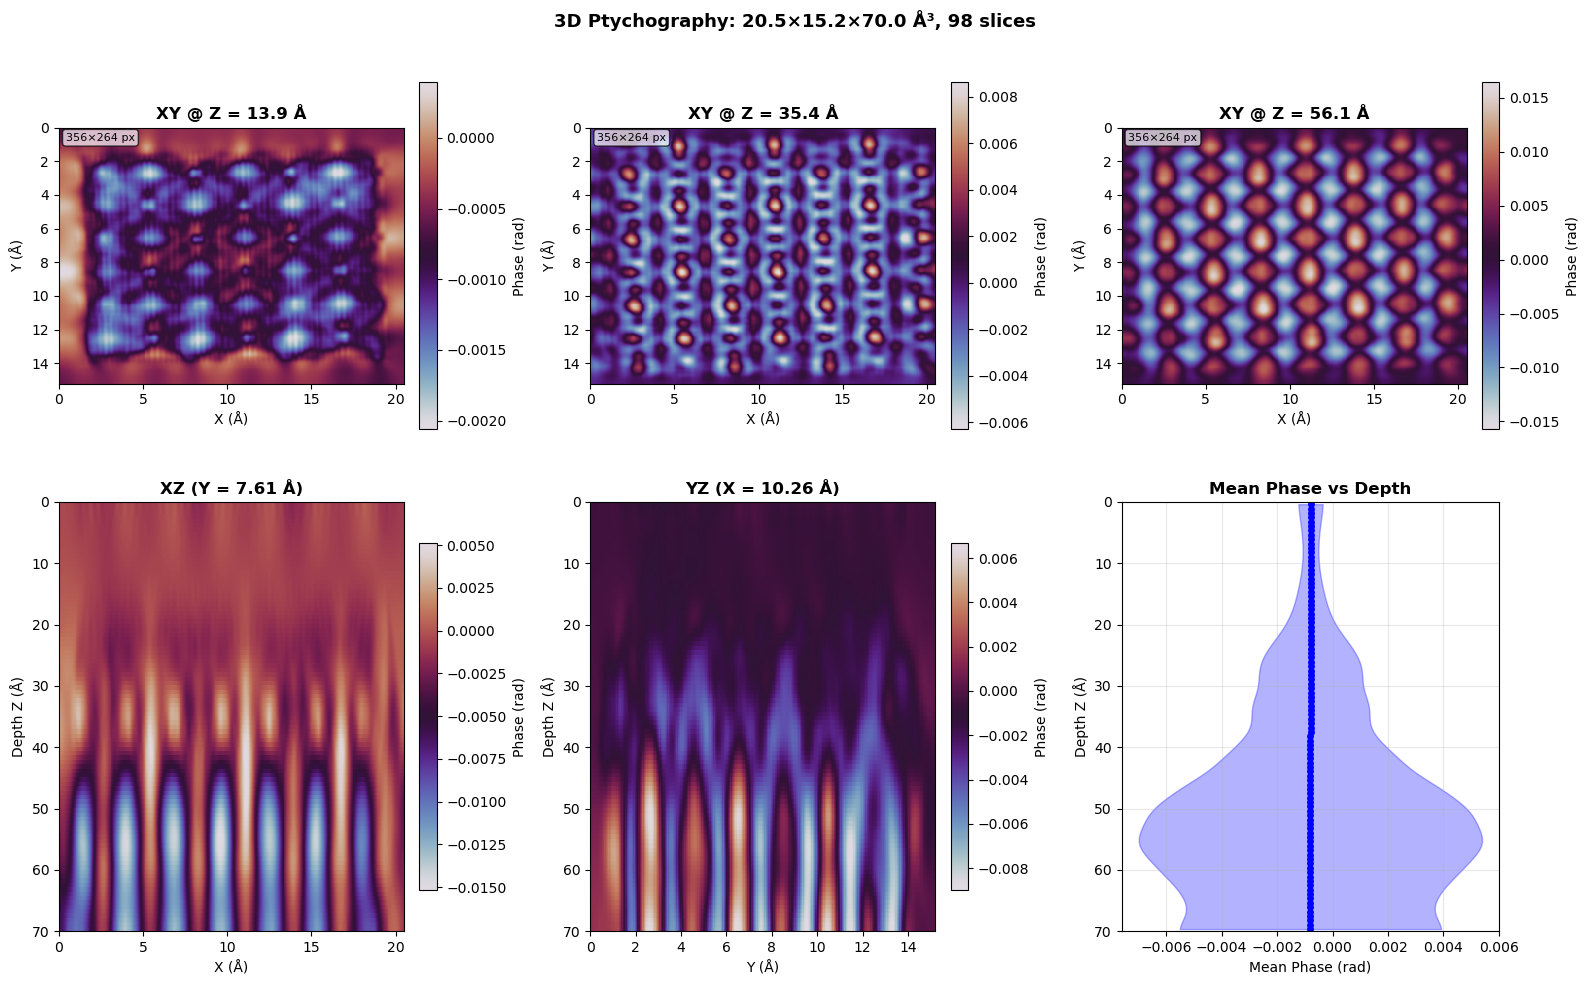


DIAGNOSTICS
Shape: (98, 264, 356)
FOV: 20.51 × 15.21 Å²
Pixel size: 0.0576 Å
Phase range: [-0.016, 0.017] rad


In [10]:
'''Ptychography Visualization - CORRECTED'''
import numpy as np
import matplotlib.pyplot as plt

# Load data
print("Loading reconstruction...")
data = np.load('ptycho_3d_reconstruction.npz')

object_phase = data['object_phase']
num_slices = int(data['num_slices'])
real_space_thickness = float(data['real_space_thickness'])
recon_pixel_size = float(data['reconstruction_pixel_size'])

print(f"✓ Loaded: {object_phase.shape}")
print(f"  Pixel size: {recon_pixel_size:.4f} Å")
print(f"  Depth: {real_space_thickness:.2f} Å")

# Get dimensions
nz, ny, nx = object_phase.shape

# Calculate physical extents
x_max = nx * recon_pixel_size
y_max = ny * recon_pixel_size
z_max = real_space_thickness

print(f"  FOV: {x_max:.2f} × {y_max:.2f} Å²")

# Extents for imshow
extent_xy = [0, x_max, y_max, 0]
extent_xz = [0, x_max, z_max, 0]
extent_yz = [0, y_max, z_max, 0]

# Z coordinates (bin centers)
z_coords = np.linspace(0, z_max, num=num_slices, endpoint=False) + (z_max / num_slices / 2)

# Create figure
fig = plt.figure(figsize=(16, 10))

# XY slices at different depths
slice_indices = [int(num_slices * 0.2), int(num_slices * 0.5), int(num_slices * 0.8)]

for i, idx in enumerate(slice_indices):
    ax = fig.add_subplot(2, 3, i+1)
    im = ax.imshow(object_phase[idx, :, :], cmap='twilight', extent=extent_xy, 
                   origin='upper', interpolation='nearest')
    ax.set_title(f"XY @ Z = {z_coords[idx]:.1f} Å", fontweight='bold')
    ax.set_xlabel("X (Å)")
    ax.set_ylabel("Y (Å)")
    plt.colorbar(im, ax=ax, label="Phase (rad)", fraction=0.046, pad=0.04)
    ax.text(0.02, 0.98, f"{nx}×{ny} px", transform=ax.transAxes,
            fontsize=8, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# XZ cross-section
ax_xz = fig.add_subplot(2, 3, 4)
mid_y = ny // 2
xz_plane = object_phase[:, mid_y, :]
im_xz = ax_xz.imshow(xz_plane, cmap='twilight', aspect='auto', extent=extent_xz, 
                     origin='upper', interpolation='nearest')
ax_xz.set_title(f"XZ (Y = {mid_y * recon_pixel_size:.2f} Å)", fontweight='bold')
ax_xz.set_xlabel("X (Å)")
ax_xz.set_ylabel("Depth Z (Å)")
plt.colorbar(im_xz, ax=ax_xz, label="Phase (rad)", fraction=0.046, pad=0.04)

# YZ cross-section
ax_yz = fig.add_subplot(2, 3, 5)
mid_x = nx // 2
yz_plane = object_phase[:, :, mid_x]
im_yz = ax_yz.imshow(yz_plane, cmap='twilight', aspect='auto', extent=extent_yz, 
                     origin='upper', interpolation='nearest')
ax_yz.set_title(f"YZ (X = {mid_x * recon_pixel_size:.2f} Å)", fontweight='bold')
ax_yz.set_xlabel("Y (Å)")
ax_yz.set_ylabel("Depth Z (Å)")
plt.colorbar(im_yz, ax=ax_yz, label="Phase (rad)", fraction=0.046, pad=0.04)

# Mean phase vs depth
ax_prof = fig.add_subplot(2, 3, 6)
mean_phase = np.mean(object_phase, axis=(1, 2))
std_phase = np.std(object_phase, axis=(1, 2))
ax_prof.plot(mean_phase, z_coords, 'o-', markersize=4, color='blue', linewidth=2)
ax_prof.fill_betweenx(z_coords, mean_phase - std_phase, mean_phase + std_phase, 
                      alpha=0.3, color='blue')
ax_prof.set_ylim(z_max, 0)
ax_prof.set_title("Mean Phase vs Depth", fontweight='bold')
ax_prof.set_xlabel("Mean Phase (rad)")
ax_prof.set_ylabel("Depth Z (Å)")
ax_prof.grid(True, alpha=0.3)

plt.suptitle(f"3D Ptychography: {x_max:.1f}×{y_max:.1f}×{z_max:.1f} Å³, {num_slices} slices", 
            fontsize=13, fontweight='bold')
plt.tight_layout()

plot_file = 'ptycho_3d_final.png'
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved to '{plot_file}'")
plt.show()

print(f"\n{'='*70}")
print("DIAGNOSTICS")
print(f"{'='*70}")
print(f"Shape: {object_phase.shape}")
print(f"FOV: {x_max:.2f} × {y_max:.2f} Å²")
print(f"Pixel size: {recon_pixel_size:.4f} Å")
print(f"Phase range: [{np.min(object_phase):.3f}, {np.max(object_phase):.3f}] rad")
print(f"{'='*70}")

In [6]:
'''iCOM & Physics Analysis - TILED DATA VERSION'''
import os
import numpy as np
import abtem
import ase.io
import zarr
from scipy.ndimage import gaussian_filter

# ==========================================
# TILED DATA CONFIGURATION
# ==========================================
# Define your tile grid (must match simulation)
TILE_ROWS = 3  # Number of tiles in Y direction (40 Å / 4 Å)
TILE_COLS = 3  # Number of tiles in X direction (40 Å / 4 Å)

# Generate tile filenames automatically
def generate_tile_filenames(prefix="tile", suffix_haadf="_haadf.zarr", suffix_bf="_bf.zarr"):
    """Generate list of tile filenames based on grid"""
    haadf_files = []
    bf_files = []
    for i in range(TILE_ROWS):
        for j in range(TILE_COLS):
            haadf_files.append(f"{prefix}{i}{j}{suffix_haadf}")
            bf_files.append(f"{prefix}{i}{j}{suffix_bf}")
    return haadf_files, bf_files

# Generate filenames
HAADF_TILE_FILES, BF_TILE_FILES = generate_tile_filenames()

# OR manually specify if you only want a subset:
# HAADF_TILE_FILES = ["tile00_haadf.zarr", "tile01_haadf.zarr", ...]
# BF_TILE_FILES = ["tile00_bf.zarr", "tile01_bf.zarr", ...]

# ==========================================
# UPDATED PARAMETERS (from simulation)
# ==========================================
SCAN_CENTER_X = 23.0       # Matches simulation
SCAN_CENTER_Y = 35.0       # Matches simulation
SCAN_STEP_A = 0.03         # 0.03 Å (matches simulation)
SCAN_WIDTH = 40.0          # Total scan area width (Å)
DETECTOR_MAX_MRAD = 250.0  # From simulation BF_MAX_ANGLE

# Structure file
STRUCTURE_FILE = "PTO6_STO6_18_18_labyrinthPoscar.vasp"

# Output
OUTPUT_FILE = "PTO_STO_Tiled_Processed_Data.npz"

# SMOOTHING SETTINGS
SIGMA_PHYSICS = 0#1.5   # For iCOM & Curl
SIGMA_VECTORS = 8.0   # For vector field display

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def to_cpu(arr):
    """Convert various array types to numpy"""
    if hasattr(arr, 'compute'):
        arr = arr.compute()
    if hasattr(arr, 'array'):
        arr = arr.array
    if hasattr(arr, 'get'):
        return arr.get()
    if hasattr(arr, 'asnumpy'):
        return arr.asnumpy()
    return np.array(arr)

def load_and_stitch_tiles(tile_files, tile_rows, tile_cols, description="data"):
    """Load tiled zarr files and stitch them into a single array"""
    print(f"   Loading and stitching {len(tile_files)} {description} tiles...")
    
    # Check which files exist
    existing_files = [f for f in tile_files if os.path.exists(f)]
    if len(existing_files) == 0:
        raise FileNotFoundError(f"No {description} tile files found!")
    
    print(f"   Found {len(existing_files)}/{len(tile_files)} tiles")
    
    # Load first tile to get shape
    first_tile = zarr.open(existing_files[0], mode='r')
    tile_shape = first_tile.shape
    
    print(f"   Individual tile shape: {tile_shape}")
    
    # Create mapping of which tiles we have
    tile_map = {}
    for filepath in existing_files:
        basename = os.path.basename(filepath)
        if 'tile' in basename:
            try:
                start_idx = basename.index('tile') + 4
                end_idx = start_idx
                while end_idx < len(basename) and basename[end_idx].isdigit():
                    end_idx += 1
                indices = basename[start_idx:end_idx]
                if len(indices) >= 2:
                    i = int(indices[0])
                    j = int(indices[1])
                    tile_map[(i, j)] = filepath
            except (ValueError, IndexError):
                print(f"   Warning: Could not parse indices from {filepath}")
                continue
    
    # Calculate total stitched shape
    if len(tile_shape) == 2:  # HAADF: (scan_y, scan_x)
        total_shape = (tile_rows * tile_shape[0], tile_cols * tile_shape[1])
    elif len(tile_shape) == 4:  # BF: (scan_y, scan_x, det_y, det_x)
        total_shape = (tile_rows * tile_shape[0], tile_cols * tile_shape[1], 
                      tile_shape[2], tile_shape[3])
    else:
        raise ValueError(f"Unexpected tile shape: {tile_shape}")
    
    print(f"   Stitching to: {total_shape}")
    
    # Pre-allocate full array
    full_data = np.zeros(total_shape, dtype=first_tile.dtype)
    
    # Stitch tiles
    for i in range(tile_rows):
        for j in range(tile_cols):
            if (i, j) in tile_map:
                tile_path = tile_map[(i, j)]
                print(f"   Loading tile [{i},{j}]: {os.path.basename(tile_path)}")
                tile_data = np.array(zarr.open(tile_path, mode='r'))
                
                # Calculate position in stitched array
                y_start = i * tile_shape[0]
                y_end = y_start + tile_data.shape[0]
                x_start = j * tile_shape[1]
                x_end = x_start + tile_data.shape[1]
                
                if len(tile_shape) == 2:
                    full_data[y_start:y_end, x_start:x_end] = tile_data
                else:
                    full_data[y_start:y_end, x_start:x_end, :, :] = tile_data
            else:
                print(f"   Warning: Tile [{i},{j}] missing, leaving zeros")
    
    return full_data

# ==========================================
# MAIN ANALYSIS FUNCTION
# ==========================================

def export_data():
    print("=" * 60)
    print("iCOM & PHYSICS ANALYSIS - TILED DATA")
    print("=" * 60)
    
    # --- A. LOAD HAADF TILES ---
    print("\n[1/4] Loading HAADF tiles...")
    haadf = load_and_stitch_tiles(HAADF_TILE_FILES, TILE_ROWS, TILE_COLS, "HAADF")
    
    ny, nx = haadf.shape
    real_h = ny * SCAN_STEP_A
    real_w = nx * SCAN_STEP_A
    
    print(f"\n✓ Stitched HAADF shape: {haadf.shape}")
    print(f"   Field of view: {real_w:.1f} x {real_h:.1f} Å")
    print(f"   Expected: {SCAN_WIDTH:.1f} x {SCAN_WIDTH:.1f} Å")
    
    # --- B. LOAD BF TILES & COMPUTE CoM ---
    print(f"\n[2/4] Loading BF tiles and computing Center of Mass...")
    bf_data = load_and_stitch_tiles(BF_TILE_FILES, TILE_ROWS, TILE_COLS, "BF")
    
    ny, nx, ndy, ndx = bf_data.shape
    print(f"✓ Stitched BF shape: {bf_data.shape}")
    
    # Calculate reciprocal sampling
    recip_step = DETECTOR_MAX_MRAD / (ndx / 2)
    print(f"   Reciprocal space sampling: {recip_step:.3f} mrad/pixel")
    
    # Compute Center of Mass manually
    print("   Computing CoM vectors...")
    qy_grid, qx_grid = np.meshgrid(
        np.arange(ndy) - ndy // 2,
        np.arange(ndx) - ndx // 2,
        indexing='ij'
    )
    
    # Weight by intensity and calculate COM
    total_intensity = bf_data.sum(axis=(2, 3), keepdims=True)
    total_intensity[total_intensity == 0] = 1  # Avoid division by zero
    
    U_raw = (bf_data * qx_grid).sum(axis=(2, 3)) / total_intensity.squeeze()
    V_raw = (bf_data * qy_grid).sum(axis=(2, 3)) / total_intensity.squeeze()
    
    # Convert to physical units (mrad)
    U_raw = U_raw * recip_step
    V_raw = V_raw * recip_step
    
    U_raw = U_raw.astype(np.float32)
    V_raw = V_raw.astype(np.float32)
    
    print(f"✓ CoM computed: U range [{U_raw.min():.2f}, {U_raw.max():.2f}] mrad")
    print(f"                V range [{V_raw.min():.2f}, {V_raw.max():.2f}] mrad")
    
    # Free BF memory
    del bf_data
    
    # --- C. COMPUTE PHYSICS MAPS ---
    print(f"\n[3/4] Computing physics maps...")
    
    # 1. iCOM & Curl (Sharp)
    print("   Applying Gaussian smoothing (σ={:.1f})...".format(SIGMA_PHYSICS))
    U_phys = gaussian_filter(U_raw, sigma=SIGMA_PHYSICS)
    V_phys = gaussian_filter(V_raw, sigma=SIGMA_PHYSICS)
    
    print("   Computing divergence (iCOM)...")
    iCOM = -(np.gradient(U_phys, axis=1) + np.gradient(V_phys, axis=0))
    
    print("   Computing curl...")
    Curl = np.gradient(V_phys, axis=1) - np.gradient(U_phys, axis=0)
    
    # 2. Vector Field (Smooth for visualization)
    print(f"   Smoothing vectors (σ={SIGMA_VECTORS})...")
    U_smooth = gaussian_filter(U_raw, sigma=SIGMA_VECTORS)
    V_smooth = gaussian_filter(V_raw, sigma=SIGMA_VECTORS)
    Mag_smooth = np.hypot(U_smooth, V_smooth)
    
    print("✓ Physics maps computed")
    
    # --- D. ALIGN ATOMIC MODEL ---
    print(f"\n[4/4] Aligning atomic structure...")
    
    atom_plot_x = []
    atom_plot_y = []
    atom_species = []
    
    if os.path.exists(STRUCTURE_FILE):
        try:
            atoms = ase.io.read(STRUCTURE_FILE)
            atoms.rotate(-90, 'y', rotate_cell=True)
            atoms = abtem.orthogonalize_cell(atoms)
            atoms.center(axis=2, vacuum=2.0)
            
            # Define FOV boundaries
            x_min = SCAN_CENTER_X - real_w / 2
            x_max = SCAN_CENTER_X + real_w / 2
            y_min = SCAN_CENTER_Y - real_h / 2
            y_max = SCAN_CENTER_Y + real_h / 2
            
            # Filter atoms in FOV
            mask_atoms = (
                (atoms.positions[:, 0] >= x_min) & (atoms.positions[:, 0] <= x_max) &
                (atoms.positions[:, 1] >= y_min) & (atoms.positions[:, 1] <= y_max)
            )
            atoms_plot = atoms[mask_atoms]
            
            # Convert to plot coordinates
            # Plot X (horizontal) = Atom Y position
            # Plot Y (vertical) = Atom X position
            raw_atom_x = atoms_plot.positions[:, 0] - x_min
            raw_atom_y = atoms_plot.positions[:, 1] - y_min
            
            atom_plot_x = raw_atom_y  # Horizontal
            atom_plot_y = raw_atom_x  # Vertical
            atom_species = np.array(atoms_plot.get_chemical_symbols())
            
            print(f"✓ {len(atom_plot_x)} atoms aligned to FOV")
            
        except Exception as e:
            print(f"   Warning: Model alignment failed: {e}")
    else:
        print(f"   Warning: Structure file not found: {STRUCTURE_FILE}")
    
    # --- E. SAVE TO DISK ---
    print(f"\n{'='*60}")
    print(f"SAVING TO: {OUTPUT_FILE}")
    print(f"{'='*60}")
    
    np.savez_compressed(
        OUTPUT_FILE,
        # Maps
        haadf=haadf,
        icom=iCOM,
        curl=Curl,
        mag_smooth=Mag_smooth,
        u_smooth=U_smooth,
        v_smooth=V_smooth,
        u_raw=U_raw,
        v_raw=V_raw,
        
        # Atoms (plot-ready coordinates)
        atom_x=atom_plot_x,
        atom_y=atom_plot_y,
        atom_species=atom_species,
        
        # Metadata
        extent=np.array([0, real_w, 0, real_h]),
        pixel_size=SCAN_STEP_A,
        scan_center=np.array([SCAN_CENTER_X, SCAN_CENTER_Y]),
        scan_width=SCAN_WIDTH
    )
    
    file_size = os.path.getsize(OUTPUT_FILE) / 1e6
    print(f"\n✓ Data saved ({file_size:.1f} MB)")
    print(f"   - {len(atom_plot_x)} atoms included")
    print(f"   - Pixel size: {SCAN_STEP_A} Å")
    print(f"   - FOV: {real_w:.1f} x {real_h:.1f} Å")
    print("\n" + "="*60)
    print("DONE! Transfer this file to your laptop for visualization.")
    print("="*60)

# ==========================================
# EXECUTION
# ==========================================

if __name__ == "__main__":
    export_data()

iCOM & PHYSICS ANALYSIS - TILED DATA

[1/4] Loading HAADF tiles...
   Loading and stitching 9 HAADF tiles...
   Found 9/9 tiles
   Individual tile shape: (16, 16)
   Stitching to: (48, 48)
   Loading tile [0,0]: tile00_haadf.zarr
   Loading tile [0,1]: tile01_haadf.zarr
   Loading tile [0,2]: tile02_haadf.zarr
   Loading tile [1,0]: tile10_haadf.zarr
   Loading tile [1,1]: tile11_haadf.zarr
   Loading tile [1,2]: tile12_haadf.zarr
   Loading tile [2,0]: tile20_haadf.zarr
   Loading tile [2,1]: tile21_haadf.zarr
   Loading tile [2,2]: tile22_haadf.zarr

✓ Stitched HAADF shape: (48, 48)
   Field of view: 1.4 x 1.4 Å
   Expected: 40.0 x 40.0 Å

[2/4] Loading BF tiles and computing Center of Mass...
   Loading and stitching 9 BF tiles...
   Found 9/9 tiles
   Individual tile shape: (16, 16, 45, 65)
   Stitching to: (48, 48, 45, 65)
   Loading tile [0,0]: tile00_bf.zarr
   Loading tile [0,1]: tile01_bf.zarr
   Loading tile [0,2]: tile02_bf.zarr
   Loading tile [1,0]: tile10_bf.zarr
   Loadi

--- GENERATING FINAL SLIDE FROM SAVED DATA ---
Loaded PTO_STO_Tiled_Processed_Data.npz
   Image Size: 48 x 48 pixels
   Physical Size: 1.4 x 1.4 Å


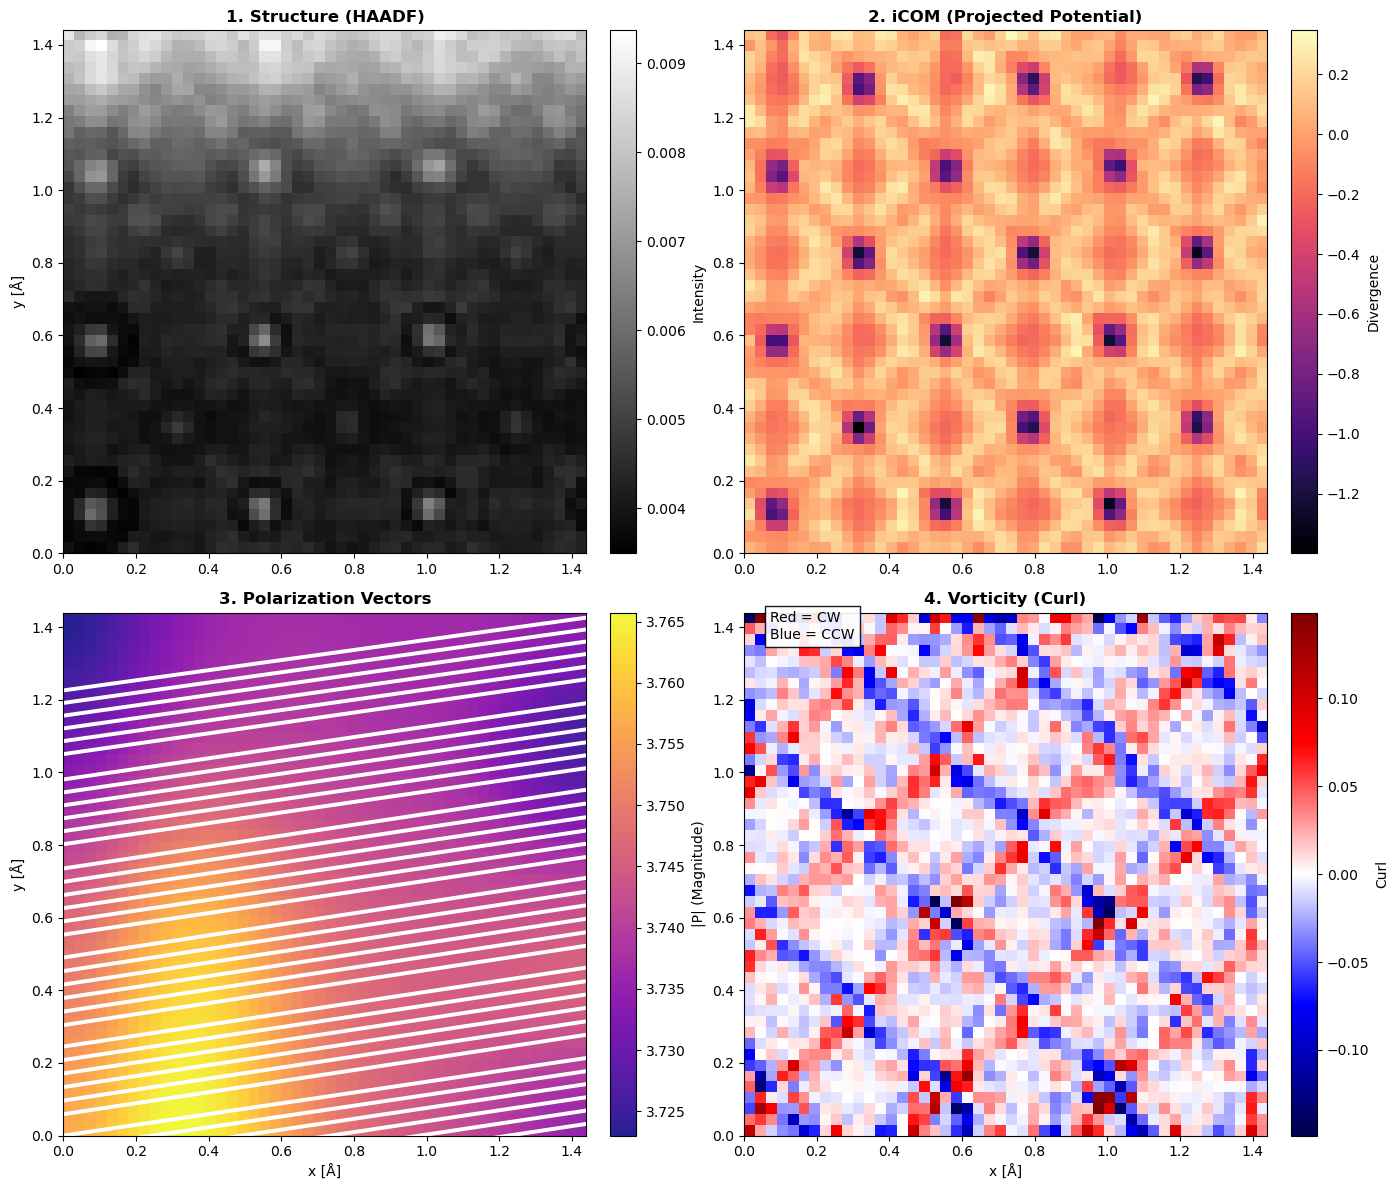

In [7]:
'''slide'''
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

#config
print("--- GENERATING FINAL SLIDE FROM SAVED DATA ---")

filename = "PTO_STO_Tiled_Processed_Data.npz"
try:
    data = np.load(filename)
    print(f"Loaded {filename}")
except FileNotFoundError:
    print(f"Error: Could not find '{filename}'. Make sure you ran the exporter script first!")
    exit()

#Extract Maps
haadf = data['haadf']
icom  = data['icom']
curl  = data['curl']
mag   = data['mag_smooth']
u_vec = data['u_smooth']
v_vec = data['v_smooth']
extent = data['extent'] # [0, w, 0, h]

#Extract Atoms
atom_x = data['atom_x']
atom_y = data['atom_y']
species = data['atom_species']

#Derive Geometry from the loaded arrays
ny, nx = haadf.shape
real_w = extent[1]
real_h = extent[3]

print(f"   Image Size: {nx} x {ny} pixels")
print(f"   Physical Size: {real_w:.1f} x {real_h:.1f} Å")

#Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Common Colorbar Settings
cbar_args = dict(fraction=0.046, pad=0.04)

# --- PANEL 1: HAADF + ATOMS ---
ax1 = axes[0, 0]
im1 = ax1.imshow(haadf, origin='lower', cmap='gray', extent=extent)
ax1.set_title("1. Structure (HAADF)", fontweight='bold')
ax1.set_ylabel("y [Å]")

# Plot Atoms by Species
# We use boolean masks to filter the arrays for each element
if len(atom_x) > 0:
    # Pb = Red
    mask = (species == 'Pb')
    ax1.scatter(atom_x[mask], atom_y[mask], c='red', s=50, edgecolors='k', linewidth=1.0, alpha=0.8)
    
    # Sr = Lime
    mask = (species == 'Sr')
    ax1.scatter(atom_x[mask], atom_y[mask], c='lime', s=50, edgecolors='k', linewidth=1.0, alpha=0.8)
    
    # Ti = Cyan
    mask = (species == 'Ti')
    ax1.scatter(atom_x[mask], atom_y[mask], c='cyan', s=50, edgecolors='k', linewidth=1.0, alpha=0.8)
    
    # O = White
    mask = (species == 'O')
    ax1.scatter(atom_x[mask], atom_y[mask], c='white', s=50, edgecolors='k', linewidth=1.0, alpha=0.8)

    # Custom Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Pb'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lime', markersize=10, label='Sr'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=10, label='Ti'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markersize=8, label='O')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', framealpha=0.9, fontsize='small')

plt.colorbar(im1, ax=ax1, label="Intensity", **cbar_args)


# --- PANEL 2: iCOM ---
ax2 = axes[0, 1]
im2 = ax2.imshow(icom, origin='lower', cmap='magma', extent=extent)
ax2.set_title("2. iCOM (Projected Potential)", fontweight='bold')
plt.colorbar(im2, ax=ax2, label="Divergence", **cbar_args)


# --- PANEL 3: VECTORS ---
ax3 = axes[1, 0]
im3 = ax3.imshow(mag, origin='lower', cmap='plasma', extent=extent, alpha=0.9)

# Reconstruct Grid for Quiver
step_x = 8
step_y = 8
x_coords = np.linspace(0, real_w, nx)
y_coords = np.linspace(0, real_h, ny)
X, Y = np.meshgrid(x_coords, y_coords)

# Subsample
X_sub = X[::step_y, ::step_x]
Y_sub = Y[::step_y, ::step_x]
U_sub = u_vec[::step_y, ::step_x]
V_sub = v_vec[::step_y, ::step_x]

ax3.quiver(X_sub, Y_sub, U_sub, V_sub, color='white', 
           scale=0.2, headwidth=4, pivot='mid')

ax3.set_title("3. Polarization Vectors", fontweight='bold')
ax3.set_ylabel("y [Å]")
ax3.set_xlabel("x [Å]")
plt.colorbar(im3, ax=ax3, label="|P| (Magnitude)", **cbar_args)


# --- PANEL 4: CURL ---
ax4 = axes[1, 1]
limit = np.max(np.abs(curl)) * 0.8
im4 = ax4.imshow(curl, origin='lower', cmap='seismic', extent=extent, vmin=-limit, vmax=limit)

ax4.set_title("4. Vorticity (Curl)", fontweight='bold')
ax4.set_xlabel("x [Å]")
ax4.text(0.05, 0.95, "Red = CW\nBlue = CCW", transform=ax4.transAxes,
         bbox=dict(facecolor='white', alpha=0.9))
plt.colorbar(im4, ax=ax4, label="Curl", **cbar_args)

plt.tight_layout()
plt.show()